# Web Scraping in Python — Programming for Machine Learning
**Instructor:** Dr. Mauricio Gruppi  
**Date:** ________


> **Important**: Always follow a website's Terms of Service, robots.txt, and be polite (rate limit). Prefer official APIs when available.

## Learning Objectives
By the end, you will be able to:
- Explain what web scraping is and when to prefer APIs.
- Use `requests` to fetch web pages and APIs.
- Parse HTML with `BeautifulSoup` to extract data.
- Read HTML tables directly into `pandas`.
- Automate a browser with `Selenium` for dynamic content.
- Apply ethical scraping practices: robots.txt and rate limiting.

## Setup
Run the cell below to install packages if needed (uncomment if running in a fresh environment). You may already have many of these.

In [67]:
# If needed, uncomment to install.
# Note: In some environments, you may need to restart the kernel after installation.
# %pip install requests beautifulsoup4 lxml pandas matplotlib selenium webdriver-manager --quiet

## Ethics & Legal Considerations
- **Check Terms of Service** before scraping.
- **Respect robots.txt** (e.g., `https://example.com/robots.txt`). Robots.txt indicates what bots are allowed to fetch.
- **Rate limit** your requests (e.g., `time.sleep(1)` between requests) to avoid overloading servers.
- **Identify yourself** with a User-Agent string when appropriate.
- **Prefer official APIs**: They are designed for programmatic access, provide structured data, and include usage policies.

---
## 1) Getting Data from Public APIs
APIs provide structured data (often JSON) and are the most stable and ethical way to collect data.

We'll use two no-auth examples:
1. **Open-Meteo** (weather, no API key)
2. **JSONPlaceholder** (fake posts, great for demos)

In [68]:
import requests

# Open-Meteo example: hourly temperature for a location (Villanova area approx.)
latitude, longitude = 40.04, -75.34
url = (
    'https://api.open-meteo.com/v1/forecast?'
    f'latitude={latitude}&longitude={longitude}&hourly=temperature_2m&timezone=auto'
)
resp = requests.get(url, timeout=20)
resp.raise_for_status()
wx = resp.json()

# Peek at structure
list(wx.keys()), wx.get('hourly', {})['time'][:3], wx.get('hourly', {})['temperature_2m'][:3]

(['latitude',
  'longitude',
  'generationtime_ms',
  'utc_offset_seconds',
  'timezone',
  'timezone_abbreviation',
  'elevation',
  'hourly_units',
  'hourly'],
 ['2026-01-29T00:00', '2026-01-29T01:00', '2026-01-29T02:00'],
 [-11.1, -11.2, -12.0])

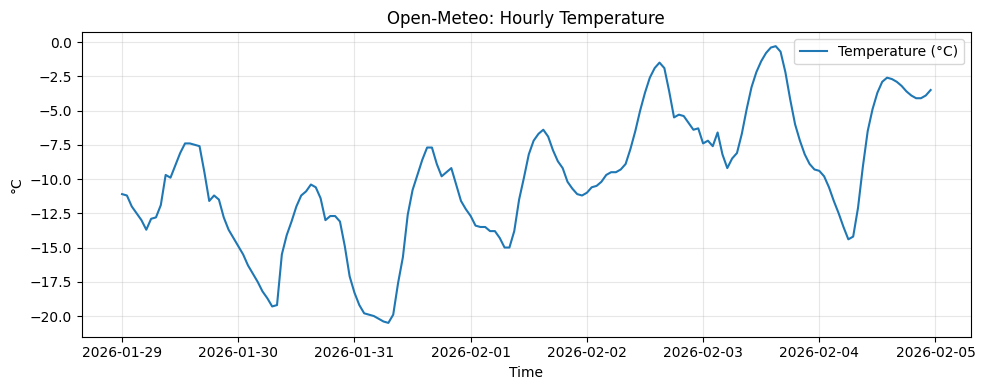

,time,temperature_C
0,2026-01-29 00:00:00,-11.1
1,2026-01-29 01:00:00,-11.2
2,2026-01-29 02:00:00,-12.0
3,2026-01-29 03:00:00,-12.5
4,2026-01-29 04:00:00,-13.0


In [69]:
# Quick visualization of the time series
import pandas as pd
import matplotlib.pyplot as plt

hourly = wx['hourly']
df_wx = pd.DataFrame({
    'time': pd.to_datetime(hourly['time']),
    'temperature_C': hourly['temperature_2m']
})

plt.figure(figsize=(10,4))
plt.plot(df_wx['time'], df_wx['temperature_C'], label='Temperature (°C)')
plt.title('Open-Meteo: Hourly Temperature')
plt.xlabel('Time')
plt.ylabel('°C')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

df_wx.head()

In [70]:
# JSONPlaceholder example: fake posts (no auth)
url = 'https://jsonplaceholder.typicode.com/posts'
resp = requests.get(url, timeout=20)
resp.raise_for_status()
posts = resp.json()

# Show the first 5 titles
[post['title'] for post in posts[:5]]

['sunt aut facere repellat provident occaecati excepturi optio reprehenderit',
 'qui est esse',
 'ea molestias quasi exercitationem repellat qui ipsa sit aut',
 'eum et est occaecati',
 'nesciunt quas odio']

### ✅ Exercise 1 — Work with a Simple API
1. Use **JSONPlaceholder** to fetch `/users` and create a table with columns: `id`, `name`, `email`, `company.name`.
2. Save the table to `users.csv`.
3. Merge `/posts` to count how many posts each user authored and sort descending.

**Starter code:**

In [71]:
import requests
import pandas as pd

# TODO: Fetch users
users_url = 'https://jsonplaceholder.typicode.com/users'
users = requests.get(users_url, timeout=20).json()

# TODO: Build DataFrame with selected fields
# HINT: each user is a dict with nested keys, e.g., user['company']['name']
rows = []
for u in users:
    rows.append({
        'id': u['id'],
        'name': u['name'],
        'email': u['email'],
        'company': u['company']['name']
    })
users_df = pd.DataFrame(rows)
users_df.head()

# TODO: Save to CSV
# users_df.to_csv('users.csv', index=False)

# TODO: Count posts per user
# posts_url = 'https://jsonplaceholder.typicode.com/posts'
# posts = requests.get(posts_url, timeout=20).json()
# posts_df = pd.DataFrame(posts)
# counts = posts_df.groupby('userId').size().reset_index(name='post_count')
# users_with_counts = users_df.merge(counts, left_on='id', right_on='userId', how='left').fillna({'post_count': 0})
# users_with_counts.sort_values('post_count', ascending=False)

,id,name,email,company
0,1,Leanne Graham,Sincere@april.biz,Romaguera-Crona
1,2,Ervin Howell,Shanna@melissa.tv,Deckow-Crist
2,3,Clementine Bauch,Nathan@yesenia.net,Romaguera-Jacobson
3,4,Patricia Lebsack,Julianne.OConner@kory.org,Robel-Corkery
4,5,Chelsey Dietrich,Lucio_Hettinger@annie.ca,Keebler LLC


---
## 2) Scraping Static Websites with BeautifulSoup
Use `requests` to fetch HTML and `BeautifulSoup` to parse it.

We'll use **Quotes to Scrape** which is intentionally built for learning: http://quotes.toscrape.com

In [72]:
import requests
from bs4 import BeautifulSoup

url = 'http://quotes.toscrape.com/'
html = requests.get(url, timeout=20).text
soup = BeautifulSoup(html, 'html.parser')

# Extract quotes and authors on the first page
quotes = []
for q in soup.select('div.quote'):
    text = q.select_one('span.text').get_text(strip=True)
    author = q.select_one('small.author').get_text(strip=True)
    tags = [t.get_text(strip=True) for t in q.select('div.tags a.tag')]
    quotes.append({'text': text, 'author': author, 'tags': tags})

len(quotes), quotes[0]

(10,
 {'text': '“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”',
  'author': 'Albert Einstein',
  'tags': ['change', 'deep-thoughts', 'thinking', 'world']})

In [73]:
# Convert to DataFrame and preview
import pandas as pd

quotes_df = pd.DataFrame(quotes)
quotes_df.head()

,text,author,tags
0,“The world as we have created it is a process ...,Albert Einstein,"[change, deep-thoughts, thinking, world]"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"[abilities, choices]"
2,“There are only two ways to live your life. On...,Albert Einstein,"[inspirational, life, live, miracle, miracles]"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"[aliteracy, books, classic, humor]"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"[be-yourself, inspirational]"


### ✅ Exercise 2 — Scrape Multiple Pages (Books to Scrape)
Website: http://books.toscrape.com

**Goal:** Scrape the first **2 pages** of catalog results to extract: `title`, `price`, `availability`, and the product `link`. Combine into a single DataFrame and save as `books_page1_2.csv`.

**Hints:**
- Start at `http://books.toscrape.com/catalogue/page-1.html`.
- Use `soup.select('article.product_pod')` to get each book.
- For links, prefix with the site base URL if the link is relative.
- Add `time.sleep(1)` between page requests.

**Starter code:**

In [74]:
import time
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin

base = 'http://books.toscrape.com/'
rows = []

for page in [1, 2]:
    url = f'http://books.toscrape.com/catalogue/page-{page}.html'
    print('Fetching:', url)
    html = requests.get(url, timeout=20).text
    soup = BeautifulSoup(html, 'html.parser')
    for art in soup.select('article.product_pod'):
        title = art.h3.a['title']
        price = art.select_one('p.price_color').get_text(strip=True)
        availability = art.select_one('p.instock.availability').get_text(strip=True)
        link = urljoin(base, art.h3.a['href'])
        rows.append({'title': title, 'price': price, 'availability': availability, 'link': link})
    time.sleep(1)  # polite pause

books_df = pd.DataFrame(rows)
print(books_df.shape)
books_df.head()

# books_df.to_csv('books_page1_2.csv', index=False)

Fetching: http://books.toscrape.com/catalogue/page-1.html
Fetching: http://books.toscrape.com/catalogue/page-2.html
(40, 4)


,title,price,availability,link
0,A Light in the Attic,Â£51.77,In stock,http://books.toscrape.com/a-light-in-the-attic...
1,Tipping the Velvet,Â£53.74,In stock,http://books.toscrape.com/tipping-the-velvet_9...
2,Soumission,Â£50.10,In stock,http://books.toscrape.com/soumission_998/index...
3,Sharp Objects,Â£47.82,In stock,http://books.toscrape.com/sharp-objects_997/in...
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,http://books.toscrape.com/sapiens-a-brief-hist...


---
## 3) Reading HTML Tables with `pandas.read_html`
`pandas` can parse many well-structured HTML tables automatically using the built-in `lxml` parser.

We'll read a table from Wikipedia as a demo.

In [75]:
import pandas as pd

url = 'http://en.wikipedia.org/wiki/List_of_countries_by_population_(United_Nations)'
tables = pd.read_html(url)
len(tables), [t.shape for t in tables[:3]]

HTTPError: HTTP Error 403: Forbidden

Notice the HTTP error `403: Forbidden`. This happens because our bot is making an unpolite request by not identifying it self.

We can fix that by sending information in the request headers:

In [ ]:
import pandas as pd
# User headers to identify yourself
headers = {
    'User-Agent': 'MLClassScraper/1.0 (+ CS @ Villanova University)',  # Identify yourself
    'Accept-Language': 'en-US,en;q=0.9', 
    'Accept-Encoding': 'gzip'  # Accept compressed data to reduce bandwidth usage
}

url = 'http://en.wikipedia.org/wiki/List_of_countries_by_population_(United_Nations)'
tables = pd.read_html(url, storage_options=headers)
len(tables), [t.shape for t in tables[:3]]

In [ ]:
tables[0].head()

In [ ]:
# Pick the first table and inspect
pop_df = tables[0]
pop_df.head()

In [ ]:
# Clean up and plot the top 10 by population if the columns are present
import matplotlib.pyplot as plt

# Heuristic cleaning (columns vary by page version)
cols = [c for c in pop_df.columns]
print(cols)

# Try to identify country and population columns
country_col = [c for c in cols if 'Country' in str(c) or 'country' in str(c)]
pop_col = [c for c in cols if 'Population' in str(c) or 'population' in str(c)]
if country_col and pop_col:
    ccol, pcol = country_col[0], pop_col[0]
    tmp = pop_df[[ccol, pcol]].copy()
    tmp[pcol] = (
        tmp[pcol]
        .astype(str)
        .str.replace(r'[^0-9]', '', regex=True)
        .replace('', '0')
        .astype('int64')
    )
    top10 = tmp.sort_values(pcol, ascending=False).head(10)
    plt.figure(figsize=(10,4))
    plt.barh(top10[ccol], top10[pcol])
    plt.gca().invert_yaxis()
    plt.title('Top 10 Countries by Population (from Wikipedia table)')
    plt.xlabel('Population')
    plt.tight_layout()
    plt.show()
else:
    print('Could not automatically identify columns; inspect pop_df manually.')

### ✅ Exercise 3 — Explore an HTML Table
Pick a Wikipedia page with a table (e.g., GDP, life expectancy, Olympic medals). Use `pandas.read_html` to:
1. Load the tables and choose the one you want.
2. Clean the relevant numeric column(s).
3. Plot the top 10.

**Starter code:**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# TODO: Choose your page
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)'  # example, feel free to change
all_tables = pd.read_html(url)
print(f'Found {len(all_tables)} tables')

df = all_tables[0].copy()  # adjust index after inspecting
print(df.head())

# TODO: Clean numeric columns and plot top 10
# Example cleaning (adjust column names):
# df['GDP_USD'] = df['GDP(US$million)'].astype(str).str.replace(r'[^0-9]', '', regex=True).replace('', '0').astype(int)
# top10 = df.sort_values('GDP_USD', ascending=False).head(10)
# top10.plot(kind='barh', x='Country', y='GDP_USD', figsize=(10,4), title='Top 10 GDP (nominal)')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

---
## 4) Dynamic Websites with Selenium (Concept only)
Some sites load data with JavaScript after the initial HTML loads. In those cases, `requests` won't see the final content. Use **Selenium** to control a headless browser and inspect the rendered page.

> **Note**: Running Selenium requires a browser driver. Using `webdriver-manager` simplifies setup.

__Sample code__:

In [ ]:
# This cell is for reference and may not run in your environment without proper setup.
# from selenium import webdriver
# from selenium.webdriver.chrome.service import Service
# from selenium.webdriver.common.by import By
# from webdriver_manager.chrome import ChromeDriverManager
# from selenium.webdriver.chrome.options import Options

# options = Options()
# options.add_argument('--headless=new')
# driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
# driver.get('https://quotes.toscrape.com/js/')  # JavaScript-rendered version
# items = driver.find_elements(By.CSS_SELECTOR, 'div.quote span.text')
# print([it.text for it in items[:3]])
# driver.quit()

---
## 5) Robots.txt & Rate Limiting
Always check a site's `robots.txt` for guidance on what is allowed. This is advisory (not a legal document) but good practice.

In [ ]:
import requests

robots_url = 'http://books.toscrape.com/robots.txt'
resp = requests.get(robots_url, timeout=20)
print('Status:', resp.status_code)
print(resp.text or '(No robots.txt found)')

### ✅ Exercise 4 — Be a Polite Scraper
Modify your **Exercise 2** solution to:
1. Set a custom `User-Agent` header.
2. Add a 1–2 second delay between page fetches.
3. Implement a simple retry (up to 3 attempts) if a request fails with a non-200 status.

**Starter code (pattern):**

In [ ]:
import time
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

headers = {
    'User-Agent': 'MLClassScraper/1.0 (+ CS @ Villanova University)',  # Identify yourself
    'Accept-Language': 'en-US,en;q=0.9', 
    'Accept-Encoding': 'gzip'  # Accept compressed data to reduce bandwidth usage
}

for page in [1, 2]:
    url = f'http://books.toscrape.com/catalogue/page-{page}.html'
    for attempt in range(3):
        try:
            r = requests.get(url, headers=headers, timeout=20)
            if r.status_code == 200:
                soup = BeautifulSoup(r.text, 'html.parser')
                print(f'Parsed page {page} OK, length={len(r.text)}')
                break
            else:
                print(f'Attempt {attempt+1}: status {r.status_code}')
        except Exception as e:
            print(f'Attempt {attempt+1} failed: {e}')
        time.sleep(2)
    time.sleep(1)

---
## 6) Saving Your Data
Store your scraped data to CSV or JSON for later use in analysis or ML pipelines.

In [ ]:
# Example: Save the quotes data gathered earlier
try:
    quotes_df.to_csv('quotes_sample.csv', index=False)
    print('Saved quotes_sample.csv')
except NameError:
    print('No quotes_df in memory yet. Run the scraping cell above first.')

---
## 7) Optional Mini-Projects (For ML tie-ins)
- **Sentiment**: Scrape movie or product reviews (where permitted) and train a sentiment classifier.
- **Topic Modeling**: Scrape news headlines and run LDA/topic modeling.
- **Forecasting**: Collect daily prices for a set of products to analyze trends.
- **Clustering**: Vectorize scraped text (TF–IDF) and cluster to discover themes.

> Always ensure your data collection follows site policies and local regulations.

---
## Selected Solutions
Below are example solutions for selected exercises.

### Solution Sketch — Exercise 2 (Books to Scrape, first 2 pages)

In [ ]:
import time
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin

base = 'http://books.toscrape.com/'
headers = {
    'User-Agent': 'MLClassScraper/1.0 (+ CS @ Villanova University)',  # Identify yourself
    'Accept-Language': 'en-US,en;q=0.9', 
    'Accept-Encoding': 'gzip'  # Accept compressed data to reduce bandwidth usage
}

rows = []

for page in [1, 2]:
    url = f'http://books.toscrape.com/catalogue/page-{page}.html'
    html = requests.get(url, headers=headers, timeout=20).text
    soup = BeautifulSoup(html, 'html.parser')
    for art in soup.select('article.product_pod'):
        title = art.h3.a['title']
        price = art.select_one('p.price_color').get_text(strip=True)
        availability = art.select_one('p.instock.availability').get_text(strip=True)
        link = urljoin(base, art.h3.a['href'])
        rows.append({'title': title, 'price': price, 'availability': availability, 'link': link})
    time.sleep(1)

books_df = pd.DataFrame(rows)
books_df.head()
# books_df.to_csv('books_page1_2.csv', index=False)

### Solution Sketch — Exercise 1 (Users + Post Counts)

In [ ]:
import requests
import pandas as pd

users = requests.get('https://jsonplaceholder.typicode.com/users', timeout=20).json()
posts = requests.get('https://jsonplaceholder.typicode.com/posts', timeout=20).json()

users_df = pd.DataFrame([
    {
        'id': u['id'],
        'name': u['name'],
        'email': u['email'],
        'company': u['company']['name']
    }
    for u in users
])

posts_df = pd.DataFrame(posts)
counts = posts_df.groupby('userId').size().reset_index(name='post_count')
users_with_counts = users_df.merge(counts, left_on='id', right_on='userId', how='left').fillna({'post_count': 0})
users_with_counts.sort_values('post_count', ascending=False).head()